In [4]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,confusion_matrix
import joblib
import pickle
import seaborn as sns
enc=LabelEncoder()
hot=OneHotEncoder()
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("t20I_cricket_dataset.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        40000 non-null  int64  
 1   powerPlay         40000 non-null  int64  
 2   AverageScore      40000 non-null  float64
 3   battingTeam       40000 non-null  object 
 4   bowlingTeam       40000 non-null  object 
 5   city              40000 non-null  object 
 6   delivery_left     40000 non-null  int64  
 7   score             40000 non-null  int64  
 8   CurrentRunRate    40000 non-null  float64
 9   wicketsLeft       40000 non-null  int64  
 10  Run_In_Last5      40000 non-null  float64
 11  Wickets_In_Last5  40000 non-null  float64
 12  Final_Score       40000 non-null  int64  
 13  innings           40000 non-null  int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 4.3+ MB


In [7]:
df.drop("Unnamed: 0",axis=1,inplace=True)
df.drop("powerPlay",axis=1,inplace=True)
df.drop("AverageScore",axis=1,inplace=True)

In [8]:
df

,battingTeam,bowlingTeam,city,delivery_left,score,CurrentRunRate,wicketsLeft,Run_In_Last5,Wickets_In_Last5,Final_Score,innings
0,New Zealand,Pakistan,Dubai,63,56,5.894737,8,24.0,2.0,144,1
1,Zimbabwe,Sri Lanka,Hambantota,40,76,5.700000,5,30.0,2.0,100,2
2,West Indies,Australia,St Lucia,53,68,6.089552,5,27.0,3.0,105,1
3,Australia,India,Bengaluru,18,159,9.352941,7,50.0,0.0,194,2
4,Sri Lanka,South Africa,Colombo,42,82,6.307692,7,38.0,1.0,135,2
...,...,...,...,...,...,...,...,...,...,...,...
39995,England,New Zealand,Durban,45,88,7.040000,7,27.0,3.0,159,2
39996,Pakistan,Bangladesh,Mirpur,5,135,7.043478,6,40.0,1.0,141,1
39997,New Zealand,West Indies,Lauderhill,24,117,7.312500,3,33.0,3.0,153,2
39998,Bangladesh,Sri Lanka,Chattogram,67,67,7.584906,8,39.0,2.0,166,2


In [9]:
team=enc.fit_transform(df['battingTeam'])
df.loc[:,"battingTeam"]=team
# with open("team.pkl", "wb") as f:
#     pickle.dump(team,f)

In [10]:
own=enc.fit_transform(df.loc[:,["bowlingTeam"]])
df.loc[:,"bowlingTeam"]=own
# with open ("own.pkl","wb") as f:
#   pickle.dump(own,f)


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
trans=enc.fit_transform(df.loc[:,["city"]])
df.loc[:,"city"]=trans
# with open("trans.pkl","wb") as f:
#     pickle.dump(trans,f)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [12]:
df.corr()

,battingTeam,bowlingTeam,city,delivery_left,score,CurrentRunRate,wicketsLeft,Run_In_Last5,Wickets_In_Last5,Final_Score,innings
battingTeam,1.000000,-0.172049,0.022283,-0.006794,-0.050001,-0.103741,-0.021791,-0.074992,0.018009,-0.087333,-0.033592
bowlingTeam,-0.172049,1.000000,0.018141,0.003814,0.003067,0.009028,0.023853,-0.001803,-0.014307,0.003159,0.041641
city,0.022283,0.018141,1.000000,0.004506,-0.001544,0.002547,0.015488,0.009130,-0.022527,0.015148,-0.002920
delivery_left,-0.006794,0.003814,0.004506,1.000000,-0.856161,-0.039716,0.654732,-0.131502,-0.205048,-0.087779,0.066431
score,-0.050001,0.003067,-0.001544,-0.856161,1.000000,0.512717,-0.392725,0.480867,0.095683,0.457012,-0.074375
CurrentRunRate,-0.103741,0.009028,0.002547,-0.039716,0.512717,1.000000,0.279335,0.768248,-0.180052,0.708952,-0.021036
wicketsLeft,-0.021791,0.023853,0.015488,0.654732,-0.392725,0.279335,1.000000,0.225033,-0.631543,0.288162,-0.041721
Run_In_Last5,-0.074992,-0.001803,0.009130,-0.131502,0.480867,0.768248,0.225033,1.000000,-0.306447,0.579130,-0.056484
Wickets_In_Last5,0.018009,-0.014307,-0.022527,-0.205048,0.095683,-0.180052,-0.631543,-0.306447,1.000000,-0.222458,0.034588
Final_Score,-0.087333,0.003159,0.015148,-0.087779,0.457012,0.708952,0.288162,0.579130,-0.222458,1.000000,-0.224694


In [13]:
x=df.drop("Final_Score",axis=1)
y=df.loc[:,"Final_Score"]

In [14]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=35)


In [15]:
dt=RandomForestRegressor(n_estimators=100,random_state=42)

In [16]:
dt.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
pred=dt.predict(xtest)

In [18]:
r2_score(pred,ytest)


0.8478785618927199

In [19]:
mean_squared_error(pred,ytest)

131.99439314154975

In [20]:
# joblib.dump(dt,"score.joblib")

In [21]:
model=joblib.load("score.joblib")

FileNotFoundError: [Errno 2] No such file or directory: 'score.joblib'

In [22]:
dat=[7,8,36,63,56,5.894737,8,24.0,2.0,1]

In [23]:
res=model.predict([dat])

NameError: name 'model' is not defined

In [ ]:
res

array([140.51])

In [ ]:
df["Final_Score"].max()

278

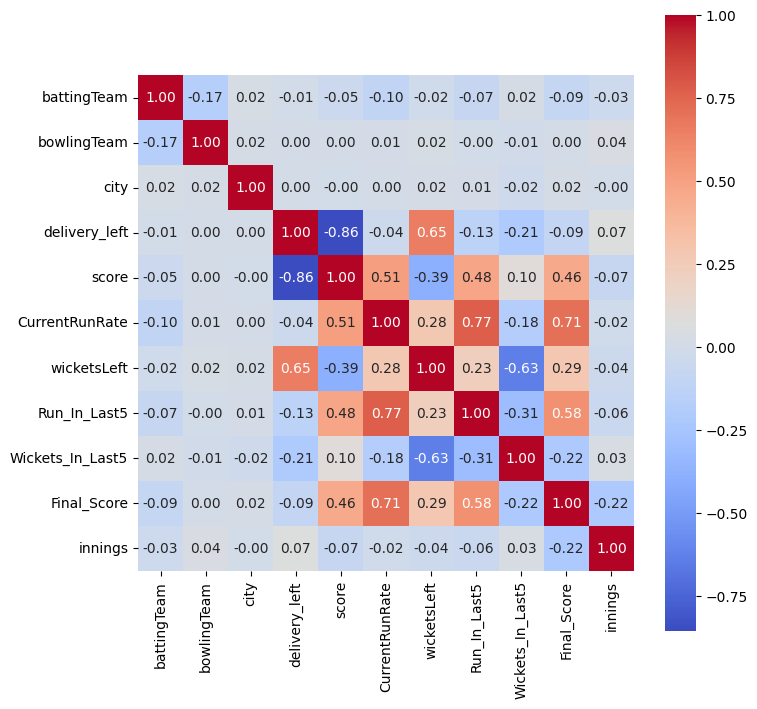

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title( label="",fontsize=16)
plt.show()

In [ ]:
!pip install tensorflow==17.0

ERROR: Could not find a version that satisfies the requirement tensorflow==17.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==17.0


In [ ]:
!pip install tensorflow==2.17.0



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
